# Random search de hiperparâmetros (sem labels)

Este notebook **não escolhe um modelo para separar True de Fake**. O objetivo é entender como
os hiperparâmetros de Isolation Forest, One-Class SVM e LOF mudam o comportamento dos detectores.

Cada configuração é sorteada de um espaço de busca, ajustada somente com `normalTrain` e medida
somente em `normalValidation`. **Nenhuma notícia Fake e nenhum label entram nas métricas**; as
partições Fake e de teste nem são usadas aqui.

> As métricas descrevem o detector (estabilidade, forma dos scores, taxa de alerta, custo),
> não sua capacidade de encontrar Fake. Uma configuração estável não é, por isso, melhor para
> detectar falsidade.

## Importando os dados preparados

In [1]:
import joblib

partitions, anomalyColumns = joblib.load("./dados_preparados.pkl")
normalTrainFrame = partitions["normalTrain"]
normalValidationFrame = partitions["normalValidation"]
print(f"normalTrain: {len(normalTrainFrame)} | normalValidation: {len(normalValidationFrame)}")

normalTrain: 2160 | normalValidation: 720


## Imports

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import kurtosis, loguniform, randint, skew, spearmanr, uniform
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.model_selection import ParameterSampler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

from anomaly_utils import anomalyScores, fitNormalOnly, nativeFlags

RANDOM_STATE = 42
N_ITER = 40
STABILITY_FRACTION = 0.80
TOP_FRACTION = 0.05

## Métricas sem label

Para cada configuração sorteada:

1. **Ajuste principal** em todo `normalTrain`, pontuando `normalValidation`:
   - `nativeAlertRate`: fração de True de validação abaixo da fronteira nativa (`predict == -1`).
     Mostra quanto o hiperparâmetro "aperta" ou "afrouxa" a fronteira.
   - `scoreSkew`, `scoreKurtosis`: forma da distribuição dos scores. Assimetria/curtose altas
     indicam que poucos pontos concentram o desvio (cauda pesada).
   - `tailRatio = (q99 − q50) / (q75 − q25)`: distância da cauda em unidades de IQR, sem depender
     da escala do score (que varia entre configurações).
   - `fitSeconds`: custo de ajuste.
2. **Estabilidade**: dois ajustes extras, cada um em uma subamostra aleatória de
   `STABILITY_FRACTION` de `normalTrain` (e, no IF, com outra semente):
   - `stabilitySpearman`: correlação de Spearman entre os rankings de `normalValidation`.
   - `stabilityTopJaccard`: Jaccard entre os `TOP_FRACTION` mais anômalos de cada ajuste.
     Mede se "quem é anômalo" depende do hiperparâmetro ou só do acaso da amostra.

In [3]:
def buildPipeline(detector, scale):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    return Pipeline(steps + [("detector", detector)])


def topSet(scores, fraction=TOP_FRACTION):
    count = max(1, int(round(len(scores) * fraction)))
    return set(np.argsort(-scores)[:count])


def stabilityMetrics(makePipeline, seeds):
    scoreRuns = []
    for seed in seeds:
        subsample = normalTrainFrame.sample(frac=STABILITY_FRACTION, random_state=seed)
        pipeline = fitNormalOnly(makePipeline(seed), subsample, anomalyColumns)
        scoreRuns.append(anomalyScores(pipeline, normalValidationFrame, anomalyColumns))
    leftTop, rightTop = topSet(scoreRuns[0]), topSet(scoreRuns[1])
    return {
        "stabilitySpearman": float(spearmanr(*scoreRuns).statistic),
        "stabilityTopJaccard": len(leftTop & rightTop) / len(leftTop | rightTop),
    }


def evaluateConfig(makePipeline, describe=None):
    fitStarted = time.perf_counter()
    pipeline = fitNormalOnly(makePipeline(RANDOM_STATE), normalTrainFrame, anomalyColumns)
    fitSeconds = time.perf_counter() - fitStarted
    scores = anomalyScores(pipeline, normalValidationFrame, anomalyColumns)
    q25, q50, q75, q99 = np.quantile(scores, [0.25, 0.50, 0.75, 0.99])
    return {
        "fitSeconds": fitSeconds,
        "nativeAlertRate": float(np.mean(nativeFlags(pipeline, normalValidationFrame, anomalyColumns))),
        "scoreSkew": float(skew(scores)),
        "scoreKurtosis": float(kurtosis(scores)),
        "tailRatio": float((q99 - q50) / (q75 - q25)) if q75 > q25 else np.nan,
        **stabilityMetrics(makePipeline, seeds=[RANDOM_STATE + 1, RANDOM_STATE + 2]),
        **(describe(pipeline) if describe else {}),
    }

## Espaços de busca

Distribuições contínuas em escala log quando o hiperparâmetro varia por ordens de grandeza.
`contamination` fica em `"auto"`: ela só desloca o offset nativo, não muda os scores.

- **IF** (sem `StandardScaler`): `n_estimators`, `max_samples` (fração do treino),
  `max_features` (número de features, 1–6), `bootstrap`.
- **OCSVM** (RBF, com `StandardScaler`): `nu`, `gamma`. Para 6 features padronizadas,
  `gamma="scale"` ≈ 1/6 ≈ 0.17, dentro do intervalo.
- **LOF** (`novelty=True`, com `StandardScaler`): `n_neighbors`, `metric`.

In [4]:
searchSpaces = {
    "IF": {
        "space": {
            "n_estimators": randint(50, 501),
            "max_samples": uniform(0.05, 0.95),
            "max_features": randint(1, len(anomalyColumns) + 1),
            "bootstrap": [False, True],
        },
        "make": lambda params: lambda seed: buildPipeline(
            IsolationForest(contamination="auto", random_state=seed, n_jobs=-1, **params), scale=False,
        ),
        "describe": None,
    },
    "OCSVM": {
        "space": {"nu": loguniform(0.005, 0.5), "gamma": loguniform(0.01, 10)},
        "make": lambda params: lambda seed: buildPipeline(OneClassSVM(kernel="rbf", **params), scale=True),
        "describe": lambda pipeline: {
            "supportVectorFraction": pipeline["detector"].support_.size / len(normalTrainFrame),
        },
    },
    "LOF": {
        "space": {"n_neighbors": randint(5, 301), "metric": ["euclidean", "manhattan", "chebyshev"]},
        "make": lambda params: lambda seed: buildPipeline(
            LocalOutlierFactor(contamination="auto", novelty=True, n_jobs=1, **params), scale=True,
        ),
        "describe": None,
    },
}

## Execução do random search

In [5]:
searchResults = {}
for modelName, spec in searchSpaces.items():
    records = []
    for params in ParameterSampler(spec["space"], n_iter=N_ITER, random_state=RANDOM_STATE):
        params = {key: value.item() if isinstance(value, np.generic) else value for key, value in params.items()}
        records.append({**params, **evaluateConfig(spec["make"](params), spec["describe"])})
    searchResults[modelName] = pd.DataFrame(records)
    print(f"{modelName}: {len(records)} configurações avaliadas")

metricColumns = ["nativeAlertRate", "stabilitySpearman", "stabilityTopJaccard", "scoreSkew", "tailRatio", "fitSeconds"]
hyperparameters = {modelName: list(spec["space"]) for modelName, spec in searchSpaces.items()}
for modelName, frame in searchResults.items():
    display(Markdown(f"**{modelName}**"))
    display(frame.describe().T.round(4))

IF: 40 configurações avaliadas


OCSVM: 40 configurações avaliadas


LOF: 40 configurações avaliadas


**IF**

,count,mean,std,min,25%,50%,75%,max
max_features,40.0,3.7000,1.5225,1.0000,3.0000,4.0000,5.0000,6.0000
max_samples,40.0,0.4981,0.2629,0.0696,0.2627,0.4818,0.6199,0.9731
n_estimators,40.0,268.6250,124.7080,62.0000,167.2500,258.5000,364.5000,498.0000
fitSeconds,40.0,0.4088,0.1818,0.0978,0.3190,0.4017,0.5102,0.7807
nativeAlertRate,40.0,0.1506,0.0453,0.0917,0.1233,0.1465,0.1684,0.3597
scoreSkew,40.0,1.9930,0.1894,1.4854,1.8964,2.0421,2.1242,2.3180
scoreKurtosis,40.0,4.8371,1.1357,2.4371,4.2342,5.0211,5.6143,7.0181
tailRatio,40.0,4.1742,0.4850,3.1047,3.8508,4.2478,4.4657,5.2087
stabilitySpearman,40.0,0.9698,0.0255,0.8659,0.9653,0.9795,0.9858,0.9918
stabilityTopJaccard,40.0,0.8652,0.0910,0.6000,0.8462,0.8947,0.9459,0.9459


**OCSVM**

,count,mean,std,min,25%,50%,75%,max
gamma,40.0,1.0532,2.0418,0.0104,0.0287,0.1259,0.7958,8.1050
nu,40.0,0.1236,0.1417,0.0062,0.0124,0.0541,0.2025,0.4707
fitSeconds,40.0,0.0535,0.0418,0.0105,0.0204,0.0442,0.0796,0.1785
nativeAlertRate,40.0,0.2105,0.1688,0.0139,0.0590,0.1722,0.3743,0.5333
scoreSkew,40.0,3.8933,1.6179,1.8115,2.5453,3.7967,4.4918,7.9876
scoreKurtosis,40.0,22.1527,19.1621,4.4612,10.0104,15.8503,21.8684,78.5856
tailRatio,40.0,45.7946,82.3583,1.3961,4.6168,10.9521,26.3650,349.5096
stabilitySpearman,40.0,0.8844,0.1522,0.4378,0.8152,0.9577,0.9941,0.9997
stabilityTopJaccard,40.0,0.8184,0.1392,0.5652,0.7143,0.8000,0.9459,1.0000
supportVectorFraction,40.0,0.2008,0.1696,0.0120,0.0534,0.1704,0.3366,0.5440


**LOF**

,count,mean,std,min,25%,50%,75%,max
n_neighbors,40.0,158.0500,87.2929,6.0000,82.7500,168.0000,241.5000,298.0000
fitSeconds,40.0,0.1160,0.0490,0.0319,0.0699,0.1194,0.1565,0.2096
nativeAlertRate,40.0,0.0598,0.0126,0.0181,0.0580,0.0625,0.0681,0.0708
scoreSkew,40.0,5.1087,0.3000,4.2211,4.8753,5.1914,5.2893,5.6422
scoreKurtosis,40.0,27.8004,5.2389,21.1365,25.5456,26.8107,29.1529,43.7205
tailRatio,40.0,37.7945,21.2599,6.4872,22.1014,30.7797,51.6607,80.9690
stabilitySpearman,40.0,0.9820,0.0422,0.7466,0.9869,0.9956,0.9976,0.9989
stabilityTopJaccard,40.0,0.9454,0.0884,0.5000,0.9459,0.9459,1.0000,1.0000


## Sensibilidade: hiperparâmetro × métrica

Correlação de Spearman entre cada hiperparâmetro numérico e cada métrica. Valores perto de ±1
indicam relação monotônica forte; perto de 0, pouca influência (ou relação não monotônica —
confira nos gráficos). Com `N_ITER` amostras, correlações pequenas são ruído.

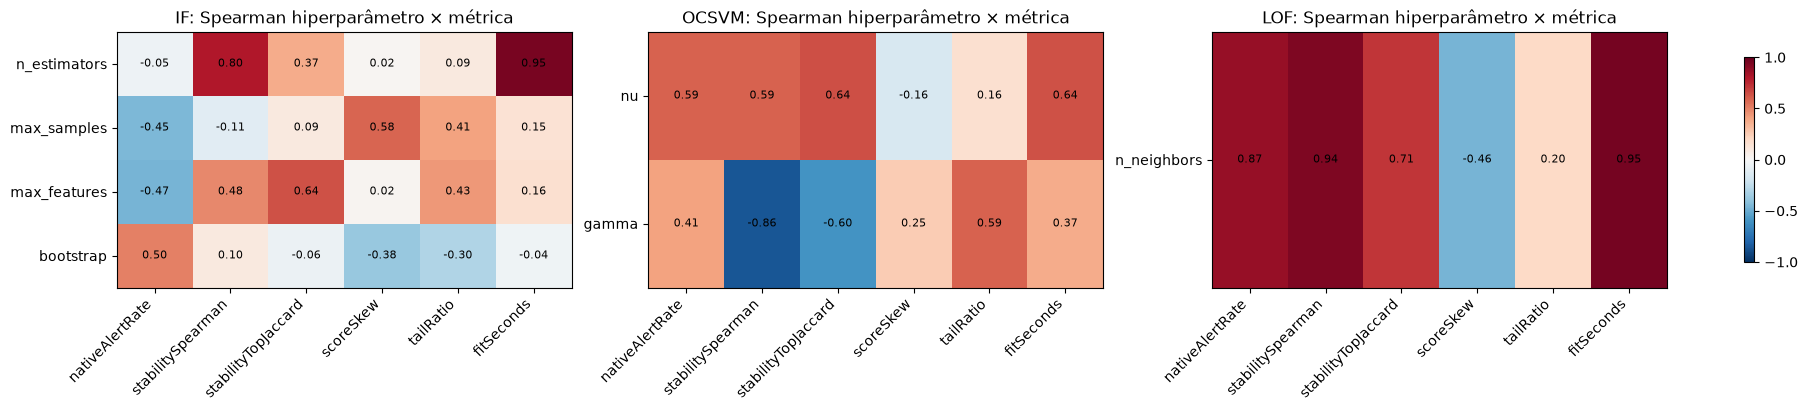

In [6]:
def sensitivityTable(frame, params):
    numericParams = [param for param in params if pd.api.types.is_numeric_dtype(frame[param])]
    return pd.DataFrame({
        param: {metric: spearmanr(frame[param], frame[metric], nan_policy="omit").statistic for metric in metricColumns}
        for param in numericParams
    }).T


sensitivity = {modelName: sensitivityTable(frame, hyperparameters[modelName]) for modelName, frame in searchResults.items()}
fig, axes = plt.subplots(1, len(sensitivity), figsize=(18, 4), constrained_layout=True)
for axis, (modelName, table) in zip(axes, sensitivity.items()):
    image = axis.imshow(table.to_numpy(dtype=float), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    axis.set_xticks(range(len(table.columns)), table.columns, rotation=45, ha="right")
    axis.set_yticks(range(len(table.index)), table.index)
    for (row, column), value in np.ndenumerate(table.to_numpy(dtype=float)):
        axis.text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=8)
    axis.set_title(f"{modelName}: Spearman hiperparâmetro × métrica")
fig.colorbar(image, ax=axes, shrink=0.8)
plt.show()

## Curvas de resposta

Cada ponto é uma configuração sorteada. Hiperparâmetros sorteados em escala log aparecem em eixo log.
Hiperparâmetros categóricos (`bootstrap`, `metric`) aparecem como cor.

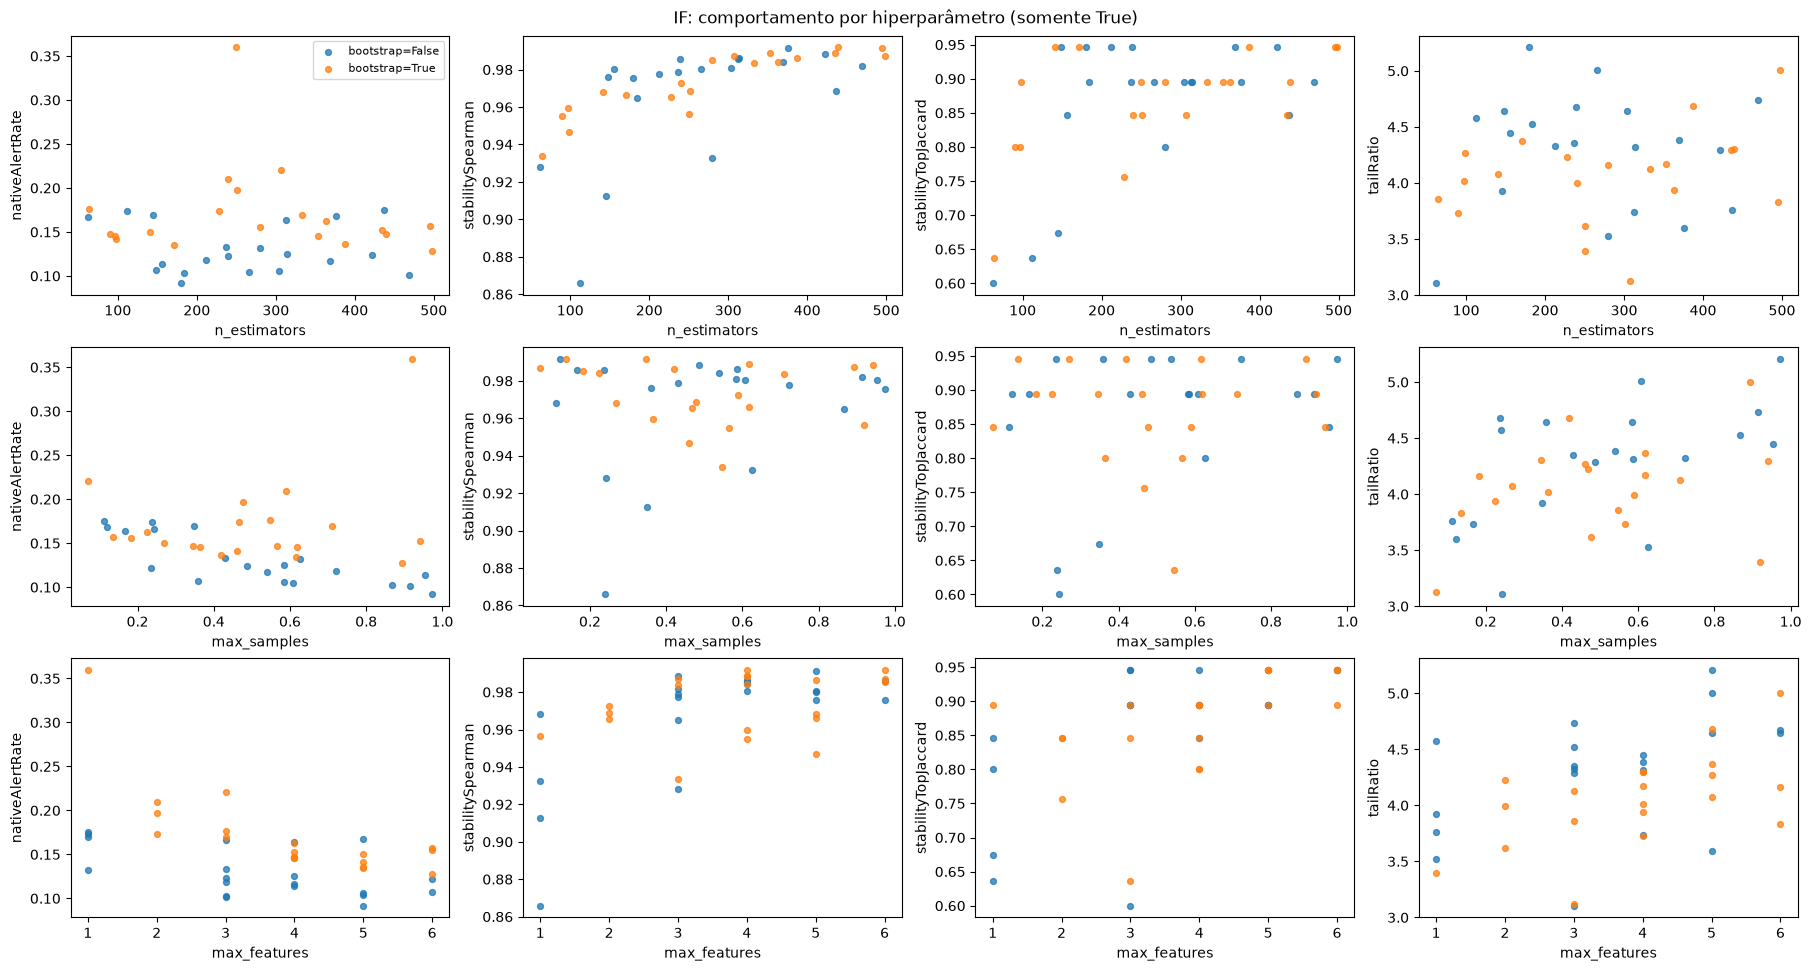

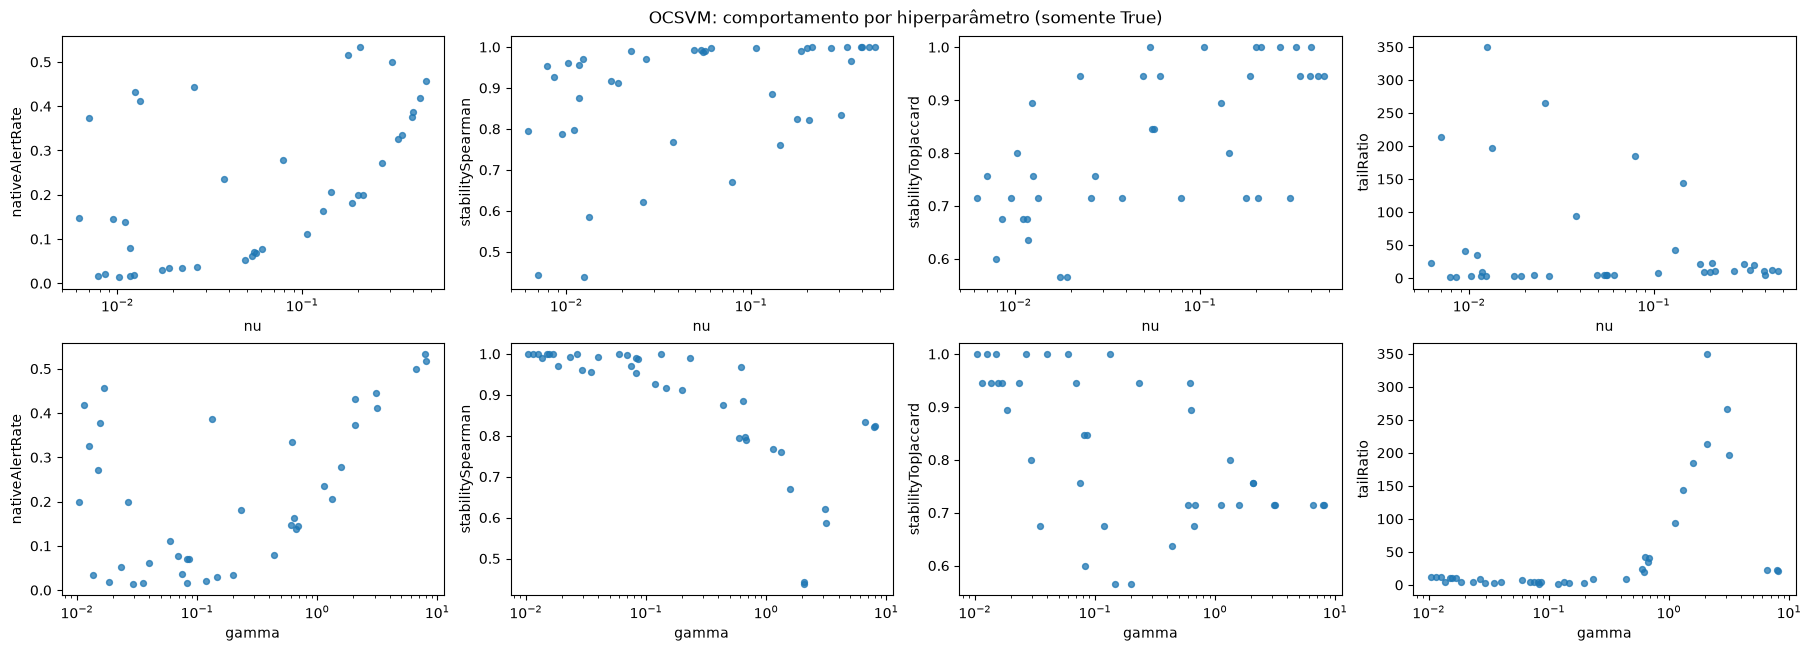

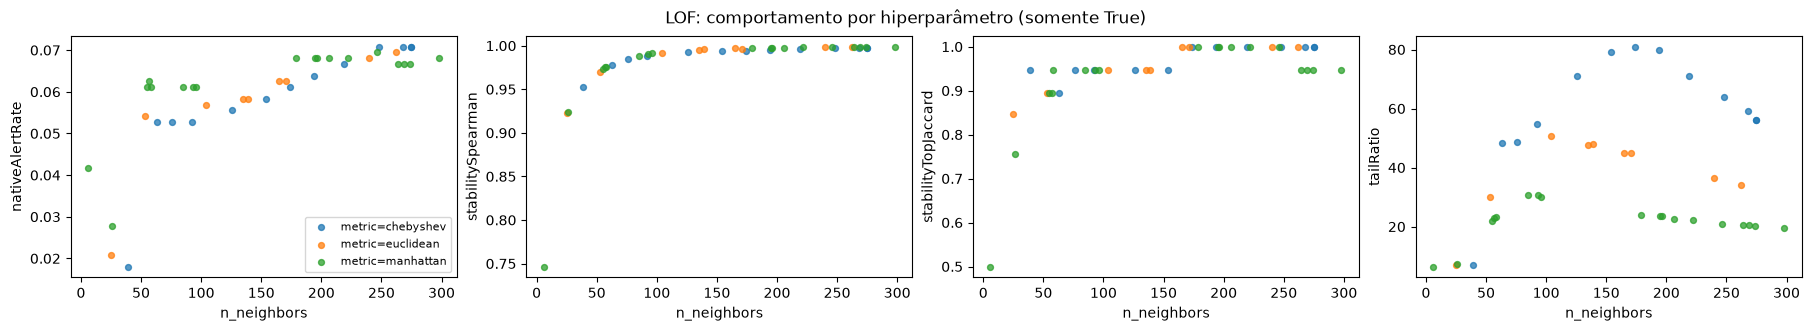

In [7]:
logScaleParams = {"nu", "gamma"}
categoricalHue = {"IF": "bootstrap", "LOF": "metric"}
responseMetrics = ["nativeAlertRate", "stabilitySpearman", "stabilityTopJaccard", "tailRatio"]

for modelName, frame in searchResults.items():
    numericParams = [param for param in hyperparameters[modelName] if param != categoricalHue.get(modelName)]
    fig, axes = plt.subplots(len(numericParams), len(responseMetrics), figsize=(18, 3.2 * len(numericParams)),
                             constrained_layout=True, squeeze=False)
    hue = categoricalHue.get(modelName)
    groups = frame.groupby(hue) if hue else [(None, frame)]
    for rowAxes, param in zip(axes, numericParams):
        for axis, metric in zip(rowAxes, responseMetrics):
            for (groupName, group), color in zip(groups, plt.cm.tab10.colors):
                axis.scatter(group[param], group[metric], s=18, alpha=0.75, color=color,
                             label=f"{hue}={groupName}" if hue else None)
            if param in logScaleParams:
                axis.set_xscale("log")
            axis.set(xlabel=param, ylabel=metric)
    if hue:
        axes[0, 0].legend(fontsize=8)
    fig.suptitle(f"{modelName}: comportamento por hiperparâmetro (somente True)")
    plt.show()

### OCSVM: interação `nu` × `gamma`

`nu` e `gamma` interagem: `gamma` alto torna a fronteira muito local (cada True vira uma "ilha"),
o que tende a elevar a fração de vetores de suporte e derrubar a estabilidade.
A taxa de alerta nativa em validação é comparada com `nu`, seu alvo teórico no treino.

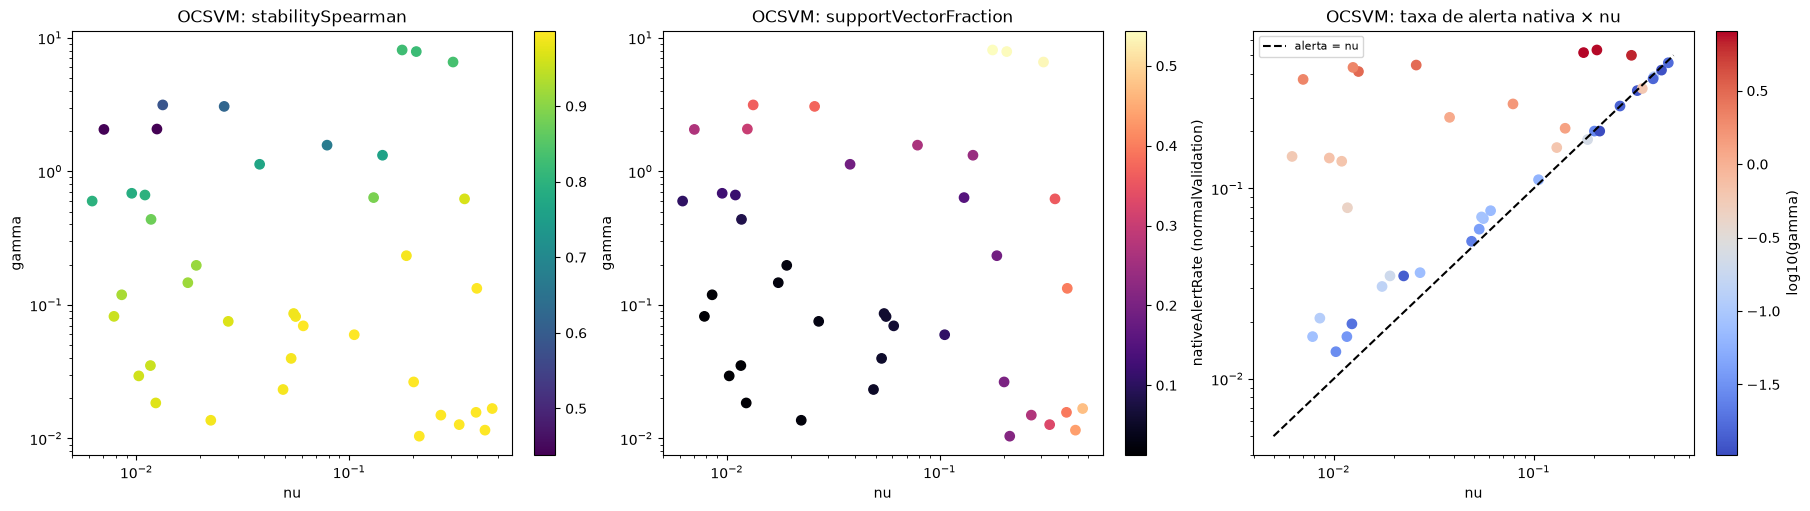

In [8]:
ocsvmFrame = searchResults["OCSVM"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for axis, metric, colormap in [
    (axes[0], "stabilitySpearman", "viridis"),
    (axes[1], "supportVectorFraction", "magma"),
]:
    points = axis.scatter(ocsvmFrame["nu"], ocsvmFrame["gamma"], c=ocsvmFrame[metric], cmap=colormap, s=45)
    axis.set(xscale="log", yscale="log", xlabel="nu", ylabel="gamma", title=f"OCSVM: {metric}")
    fig.colorbar(points, ax=axis)

points = axes[2].scatter(ocsvmFrame["nu"], ocsvmFrame["nativeAlertRate"], c=np.log10(ocsvmFrame["gamma"]), cmap="coolwarm", s=45)
axes[2].plot([0.005, 0.5], [0.005, 0.5], "k--", label="alerta = nu")
axes[2].set(xscale="log", yscale="log", xlabel="nu", ylabel="nativeAlertRate (normalValidation)",
            title="OCSVM: taxa de alerta nativa × nu")
axes[2].legend(fontsize=8)
fig.colorbar(points, ax=axes[2], label="log10(gamma)")
plt.show()

## Trade-off estabilidade × custo

Configurações mais caras nem sempre são mais estáveis. A fronteira de Pareto (maior
`stabilitySpearman` para cada nível de `fitSeconds`) mostra onde aumentar o custo deixa de compensar.

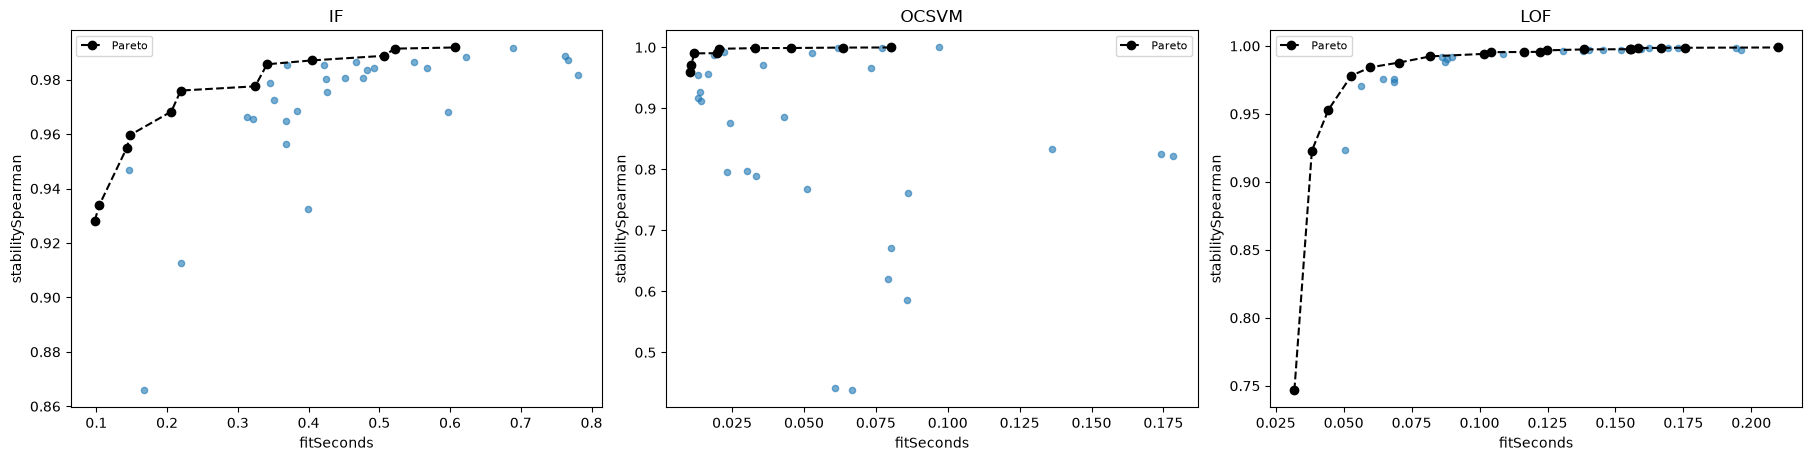

**IF: configurações na fronteira de Pareto**

,n_estimators,max_samples,max_features,bootstrap,nativeAlertRate,stabilitySpearman,stabilityTopJaccard,scoreSkew,tailRatio,fitSeconds
38,62,0.2429,3,False,0.1667,0.9282,0.6000,1.5736,3.1047,0.0978
34,64,0.5466,3,True,0.1764,0.9338,0.6364,1.9774,3.8575,0.1039
23,90,0.5656,4,True,0.1472,0.9550,0.8000,1.8871,3.7296,0.1432
29,97,0.3644,4,True,0.1458,0.9597,0.8000,1.9226,4.0154,0.1481
13,141,0.2693,5,True,0.1500,0.9683,0.9459,1.8848,4.0764,0.2060
30,148,0.3589,6,False,0.1069,0.9760,0.9459,2.0363,4.6452,0.2193
26,212,0.7215,3,False,0.1181,0.9776,0.9459,2.1704,4.3252,0.3244
20,239,0.2362,6,False,0.1222,0.9857,0.9459,2.0673,4.6755,0.3413
3,307,0.0696,3,True,0.2208,0.9871,0.8462,1.4854,3.1238,0.4042
19,353,0.6180,4,True,0.1458,0.9888,0.8947,1.9600,4.1688,0.5063


**OCSVM: configurações na fronteira de Pareto**

,nu,gamma,nativeAlertRate,stabilitySpearman,stabilityTopJaccard,scoreSkew,tailRatio,fitSeconds
2,0.0103,0.0294,0.0139,0.9601,0.8000,1.8115,2.9183,0.0105
28,0.0123,0.0184,0.0194,0.9712,0.8947,2.1479,3.8773,0.0108
29,0.0224,0.0137,0.0347,0.9901,0.9459,2.5140,4.5594,0.0118
8,0.0560,0.0818,0.0694,0.9903,0.8462,3.2066,5.0101,0.0198
32,0.0609,0.0696,0.0764,0.9975,0.9459,2.8463,4.9812,0.0206
22,0.1057,0.0598,0.1111,0.9986,1.0000,2.9613,7.3642,0.0331
33,0.2011,0.0265,0.2000,0.9988,1.0000,3.5830,9.1979,0.0453
21,0.3293,0.0127,0.3264,0.9995,1.0000,3.9416,11.5532,0.0635
5,0.4353,0.0115,0.4181,0.9997,0.9459,3.9818,12.1035,0.0801


**LOF: configurações na fronteira de Pareto**

,n_neighbors,metric,nativeAlertRate,stabilitySpearman,stabilityTopJaccard,scoreSkew,tailRatio,fitSeconds
32,6,manhattan,0.0417,0.7466,0.5000,4.2211,6.4872,0.0319
2,25,euclidean,0.0208,0.9229,0.8462,5.2726,7.1580,0.0383
30,39,chebyshev,0.0181,0.9531,0.9459,5.1743,7.1429,0.0444
15,63,chebyshev,0.0528,0.9781,0.8947,5.3197,48.1628,0.0528
1,76,chebyshev,0.0528,0.9843,0.9459,5.2861,48.6654,0.0598
5,92,chebyshev,0.0528,0.9878,0.9459,5.3087,54.7355,0.0704
3,126,chebyshev,0.0556,0.9923,0.9459,5.3112,70.8914,0.0819
7,154,chebyshev,0.0583,0.9942,0.9459,5.2659,79.2899,0.1015
21,135,euclidean,0.0583,0.9954,0.9459,5.4264,47.4934,0.1043
17,194,chebyshev,0.0639,0.9956,1.0000,5.2282,79.8396,0.1165


In [9]:
def paretoFront(frame, costColumn="fitSeconds", valueColumn="stabilitySpearman"):
    ordered = frame.sort_values(costColumn)
    return ordered[ordered[valueColumn] >= ordered[valueColumn].cummax()]


fig, axes = plt.subplots(1, len(searchResults), figsize=(18, 4.5), constrained_layout=True)
for axis, (modelName, frame) in zip(axes, searchResults.items()):
    axis.scatter(frame["fitSeconds"], frame["stabilitySpearman"], s=20, alpha=0.6)
    front = paretoFront(frame)
    axis.plot(front["fitSeconds"], front["stabilitySpearman"], "k--", marker="o", label="Pareto")
    axis.set(title=modelName, xlabel="fitSeconds", ylabel="stabilitySpearman")
    axis.legend(fontsize=8)
plt.show()

for modelName, frame in searchResults.items():
    display(Markdown(f"**{modelName}: configurações na fronteira de Pareto**"))
    display(paretoFront(frame)[hyperparameters[modelName] + metricColumns].round(4))

## Conclusão

In [10]:
lines = []
for modelName, table in sensitivity.items():
    for metric in ["nativeAlertRate", "stabilitySpearman", "tailRatio"]:
        strongest = table[metric].abs().idxmax()
        lines.append(f"- **{modelName}** · `{metric}`: hiperparâmetro mais associado é "
                     f"`{strongest}` (Spearman {table.loc[strongest, metric]:+.2f}).")
display(Markdown("\n".join(lines) + f"""

Resultados de {N_ITER} configurações por modelo, ajustadas em {len(normalTrainFrame)} True e medidas
em {len(normalValidationFrame)} True. **Nenhum label Fake foi usado.** As associações descrevem o
comportamento dos detectores neste split; não indicam qual configuração detecta melhor notícias falsas.
"""))

- **IF** · `nativeAlertRate`: hiperparâmetro mais associado é `bootstrap` (Spearman +0.50).
- **IF** · `stabilitySpearman`: hiperparâmetro mais associado é `n_estimators` (Spearman +0.80).
- **IF** · `tailRatio`: hiperparâmetro mais associado é `max_features` (Spearman +0.43).
- **OCSVM** · `nativeAlertRate`: hiperparâmetro mais associado é `nu` (Spearman +0.59).
- **OCSVM** · `stabilitySpearman`: hiperparâmetro mais associado é `gamma` (Spearman -0.86).
- **OCSVM** · `tailRatio`: hiperparâmetro mais associado é `gamma` (Spearman +0.59).
- **LOF** · `nativeAlertRate`: hiperparâmetro mais associado é `n_neighbors` (Spearman +0.87).
- **LOF** · `stabilitySpearman`: hiperparâmetro mais associado é `n_neighbors` (Spearman +0.94).
- **LOF** · `tailRatio`: hiperparâmetro mais associado é `n_neighbors` (Spearman +0.20).

Resultados de 40 configurações por modelo, ajustadas em 2160 True e medidas
em 720 True. **Nenhum label Fake foi usado.** As associações descrevem o
comportamento dos detectores neste split; não indicam qual configuração detecta melhor notícias falsas.
